## Part 3: Trotterisation

Part 2 introduced qubits, superposition, and entanglement as static circuit 
constructions. This notebook asks a different question: given a Hamiltonian 
H, how do we implement its *time evolution*, e^{-iHt}, as an actual circuit? 
For Hamiltonians with non-commuting terms, this requires Trotterisation, 
approximating the evolution as a sequence of simpler, individually-implementable rotations. This is validated first for a single qubit, then 
extended to a two-qubit interacting system where entanglement grows 
dynamically under Hamiltonian evolution.

### Exact time evolution (ground truth)

Before testing any approximation, we compute the exact evolution under 
H = aX + bZ via direct matrix exponentiation. Since X and Z don't commute, 
this Hamiltonian produces genuine quantum precession, ⟨Z⟩ oscillating over 
time, rather than settling to a fixed value.

In [1]:
import numpy as np
from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, entropy
import matplotlib.pyplot as plt

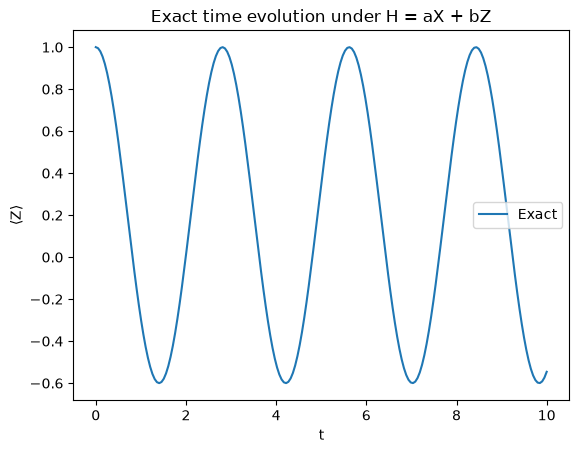

In [2]:
# Pauli matrices
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])

a, b = 1.0, 0.5   # H = aX + bZ
H = a * X + b * Z

psi0 = np.array([1, 0])   # start in |0>

def exact_evolution(H, psi0, t):
    U = expm(-1j * H * t)
    return U @ psi0

def expectation_Z(psi):
    return np.real(np.conj(psi) @ Z @ psi)

t_values = np.linspace(0, 10, 200)
exact_Z = [expectation_Z(exact_evolution(H, psi0, t)) for t in t_values]

plt.plot(t_values, exact_Z, label='Exact')
plt.xlabel('t')
plt.ylabel('⟨Z⟩')
plt.legend()
plt.title('Exact time evolution under H = aX + bZ')
plt.savefig('../figures/trotter_exact.png', dpi=120)

The oscillating ⟨Z⟩ confirms real precession driven by the non-commuting 
terms, this is the benchmark the Trotterised circuit will be checked against.

### Trotterised circuit

Since X and Z don't commute, e^{-i(aX+bZ)t} can't be implemented as a single 
gate. First-order Trotterisation approximates it by alternating Rx and Rz 
rotations over n small steps. The circuit below shows 3 steps, small enough 
to remain readable, illustrative rather than numerically converged.

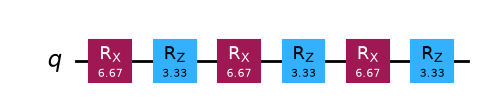

In [3]:
qc_single_example = QuantumCircuit(1)
n_example = 3
t_example = 10   # example total evolution time, just for illustrating the circuit
dt_example = t_example / n_example
for _ in range(n_example):
    qc_single_example.rx(2*a*dt_example, 0)
    qc_single_example.rz(2*b*dt_example, 0)

qc_single_example.draw('mpl')

Each repeated Rx–Rz block is one Trotter step; more steps means more 
repetitions of this same block, and better approximation to the exact 
evolution.

Comparing the Trotterised curve against the exact one directly tests this: 
at n=50 the two curves should be indistinguishable, while a low step count 
(n=3–5) should show visible disagreement.

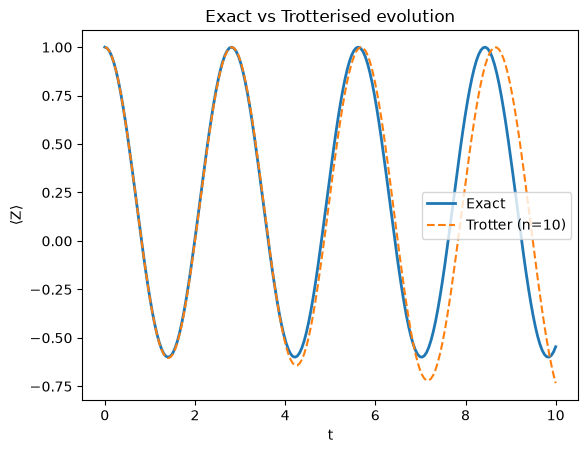

In [4]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def trotter_evolution(a, b, t, n_steps):
    """
    First-order Trotter approximation of e^{-i(aX+bZ)t}, applied to |0>.
    Qiskit convention: Rx(theta) = exp(-i*theta*X/2), so matching aX
    for a duration dt requires theta = 2*a*dt (same logic for Rz/Z).
    """
    dt = t / n_steps
    qc = QuantumCircuit(1)
    for _ in range(n_steps):
        qc.rx(2 * a * dt, 0)
        qc.rz(2 * b * dt, 0)
    return Statevector(qc)

def expectation_Z_from_state(state):
    probs = state.probabilities()
    return probs[0] - probs[1]   # <Z> = P(0) - P(1)

n_steps = 10   # try few steps first, e.g. 5, to see visible disagreement

trotter_Z = []
for t in t_values:
    state = trotter_evolution(a, b, t, n_steps)
    trotter_Z.append(expectation_Z_from_state(state))

plt.plot(t_values, exact_Z, label='Exact', linewidth=2)
plt.plot(t_values, trotter_Z, '--', label=f'Trotter (n={n_steps})')
plt.xlabel('t')
plt.ylabel('⟨Z⟩')
plt.legend()
plt.title('Exact vs Trotterised evolution')
plt.savefig('../figures/trotter_comparison.png', dpi=120)

At n=10, the Trotterised curve already tracks the exact solution closely. 
Separately testing n=3 or n=5 shows visible divergence, confirming the 
approximation genuinely depends on step count rather than being trivially 
accurate.

### Quantifying convergence

Rather than relying on visual agreement, the Trotter error (max deviation 
in ⟨Z⟩ from the exact solution) is computed explicitly across a range of 
step counts, and plotted on a log-log scale to reveal the underlying 
power-law scaling.

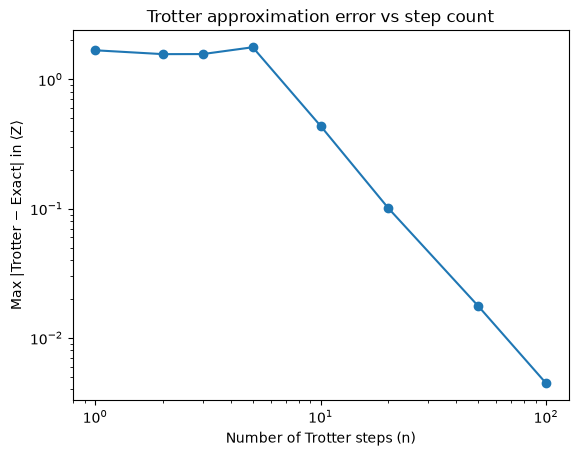

In [17]:
def trotter_error(a, b, t_max, n_steps, n_points=50):
    """
    Compute the max absolute error between exact and Trotterised <Z>
    over a range of times, for a given number of Trotter steps.
    """
    t_vals = np.linspace(0, t_max, n_points)
    errors = []
    for t in t_vals:
        exact = expectation_Z(exact_evolution(H, psi0, t))
        trotter = expectation_Z_from_state(trotter_evolution(a, b, t, n_steps))
        errors.append(abs(exact - trotter))
    return max(errors)

n_steps_list = [1, 2, 3, 5, 10, 20, 50, 100]
max_errors = [trotter_error(a, b, t_max=10, n_steps=n) for n in n_steps_list]

plt.figure()
plt.loglog(n_steps_list, max_errors, 'o-')
plt.xlabel('Number of Trotter steps (n)')
plt.ylabel('Max |Trotter − Exact| in ⟨Z⟩')
plt.title('Trotter approximation error vs step count')
plt.savefig('../figures/trotter_convergence.png', dpi=120)

### Two distinct regimes

The log-log plot reveals two regions rather than a single power law:

- **n = 1–5 (saturated regime):** error sits near 1.5–1.8, close to the 
  maximum possible difference between two numbers bounded in [-1, 1]. With 
  so few steps, the approximation is essentially uncorrelated with the true 
  answer, not yet in the regime where any scaling law applies.
- **n ≥ 10 (power-law regime):** fitting this region gives a slope of 
  approximately -2, i.e. error ~ O(1/n²), notably better than the generic 
  worst-case Trotter bound of O(1/n). This is consistent with known results 
  that generic Trotter error bounds are frequently loose for small, 
  low-dimensional systems, here, a single qubit with only two Pauli terms.

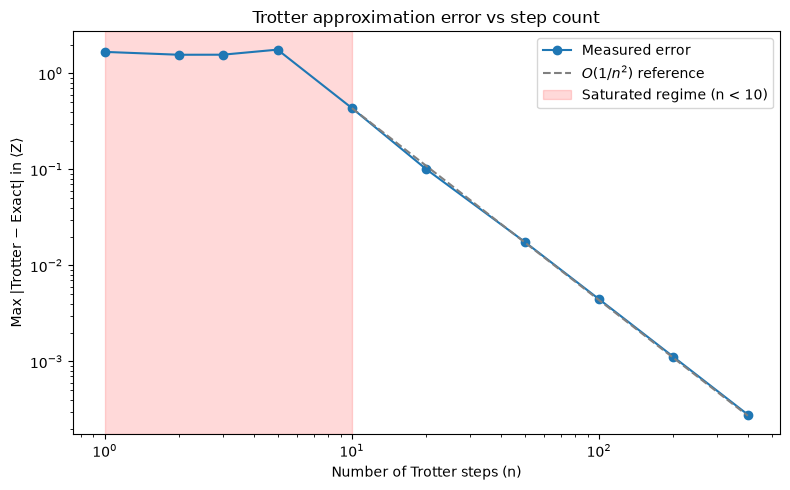

In [18]:
n_steps_list = [1, 2, 3, 5, 10, 20, 50, 100, 200, 400]
max_errors = [trotter_error(a, b, t_max=10, n_steps=n) for n in n_steps_list]

n_arr = np.array(n_steps_list)
err_arr = np.array(max_errors)

# Fit a reference O(1/n^2) line using only the post-saturation points (n>=10)
mask = n_arr >= 10
# Anchor the reference line at n=10 using the actual measured error there
C = err_arr[mask][0] * n_arr[mask][0]**2
reference_line = C / n_arr[mask]**2

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(n_arr, err_arr, 'o-', label='Measured error')
ax.loglog(n_arr[mask], reference_line, '--', color='gray', label=r'$O(1/n^2)$ reference')

# Shade the saturated region distinctly
ax.axvspan(n_arr.min(), 10, alpha=0.15, color='red', label='Saturated regime (n < 10)')

ax.set_xlabel('Number of Trotter steps (n)')
ax.set_ylabel('Max |Trotter − Exact| in ⟨Z⟩')
ax.set_title('Trotter approximation error vs step count')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/trotter_convergence_shaded.png', dpi=120)

The measured points closely follow the O(1/n²) reference line for n ≥ 10, 
with the saturated region shaded separately to make clear it does not 
belong to the same scaling regime.

### Entanglement growth under Hamiltonian evolution

Part 2 showed entanglement as a static property of a prepared state. Here, 
two qubits start completely unentangled (|00⟩) and become entangled purely 
through time evolution under an interacting Hamiltonian, 
H = J·Z₁Z₂ + h(X₁+X₂), no explicit entangling gate is applied by hand.

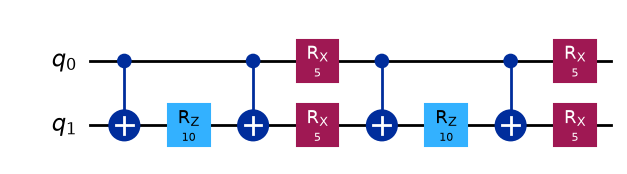

In [7]:
def zz_interaction(qc, q1, q2, angle):
    """Implements exp(-i * angle/2 * Z⊗Z) via the standard CX-Rz-CX gadget."""
    qc.cx(q1, q2)
    qc.rz(angle, q2)
    qc.cx(q1, q2)

J, h = 1.0, 0.5   # interaction strength and local field, matching your entanglement section

qc_two_example = QuantumCircuit(2)
n_example2 = 2
t_example2 = 10
dt_example2 = t_example2 / n_example2
for _ in range(n_example2):
    zz_interaction(qc_two_example, 0, 1, 2*J*dt_example2)
    qc_two_example.rx(2*h*dt_example2, 0)
    qc_two_example.rx(2*h*dt_example2, 1)

qc_two_example.draw('mpl')

## Connecting back to Part 1: symmetric vs asymmetric splitting

Part 1's split-step solver evolves the Schrödinger equation using a 
symmetric structure, half a potential step, one full kinetic step, half a 
potential step, a method known in numerical analysis as Strang splitting. 
The single-qubit Trotter circuit above used the simpler, asymmetric 
Lie-Trotter form instead. Since Strang splitting is designed to cancel 
leading-order error, it should in principle converge faster; this is 
tested directly.

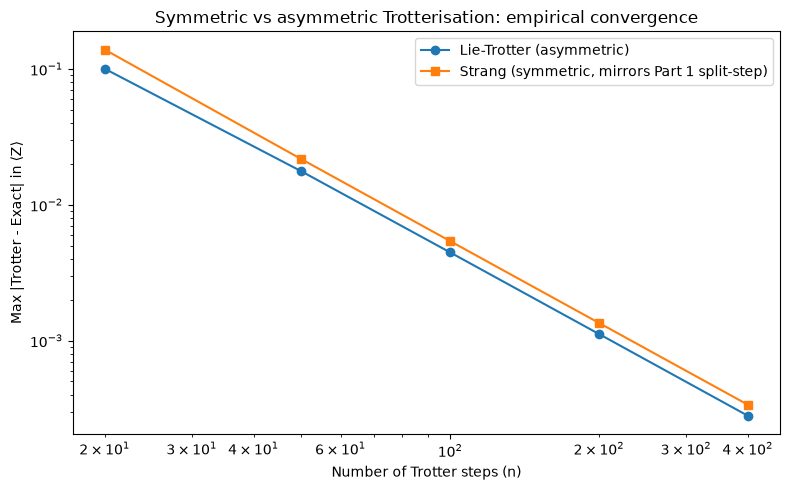

In [ ]:
def strang_trotter_state(a, b, t, n):
    """Symmetric (Strang) splitting: half-a, full-b, half-a, mirroring Part 1's split-step V/2, T, V/2 structure."""
    dt = t / n
    qc = QuantumCircuit(1)
    for _ in range(n):
        qc.rx(a*dt, 0)
        qc.rz(2*b*dt, 0)
        qc.rx(a*dt, 0)
    return Statevector(qc)

def max_error_strang(a, b, t_max, n, n_points=30):
    ts = np.linspace(0.1, t_max, n_points)
    errs = [abs(expectation_Z(exact_evolution(H, psi0, t)) - expectation_Z_from_state(strang_trotter_state(a,b,t,n))) for t in ts]
    return max(errs)

n_list_compare = [20, 50, 100, 200, 400]
errs_lie = [trotter_error(a, b, 10, n) for n in n_list_compare]  # your existing asymmetric version
errs_strang = [max_error_strang(a, b, 10, n) for n in n_list_compare]

fig, ax = plt.subplots(figsize=(8,5))
ax.loglog(n_list_compare, errs_lie, 'o-', label='Lie-Trotter (asymmetric)')
ax.loglog(n_list_compare, errs_strang, 's-', label='Strang (symmetric, mirrors Part 1 split-step)')
ax.set_xlabel('Number of Trotter steps (n)')
ax.set_ylabel('Max |Trotter - Exact| in ⟨Z⟩')
ax.set_title('Symmetric vs asymmetric Trotterisation: empirical convergence')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/trotter_symmetric_comparison.png', dpi=120)

Visually, the two curves are close but not clearly separated by eye, worth 
quantifying rather than judging by inspection.

Two checks distinguish "same scaling order, different constant" from 
"genuinely different convergence rate": fitting the log-log slope directly, 
and checking whether the ratio between the two methods' errors stays 
constant as n increases.

In [ ]:
n_list = np.array([20, 50, 100, 200, 400])
errs_lie = np.array([trotter_error(a, b, 10, n) for n in n_list])
errs_strang = np.array([max_error_strang(a, b, 10, n) for n in n_list])

slope_lie, _ = np.polyfit(np.log(n_list), np.log(errs_lie), 1)
slope_strang, _ = np.polyfit(np.log(n_list), np.log(errs_strang), 1)

print(f"Fitted slope, Lie-Trotter:  {slope_lie:.3f}")
print(f"Fitted slope, Strang:       {slope_strang:.3f}")

ratio = errs_strang / errs_lie
print(f"Error ratio (Strang/Lie) across n: {ratio}")
print(f"Coefficient of variation of ratio: {np.std(ratio)/np.mean(ratio):.3f}")

Fitted slope, Lie-Trotter:  -1.968
Fitted slope, Strang:       -2.009
Error ratio (Strang/Lie) across n: [1.38320614 1.22935969 1.21102073 1.20655363 1.205444  ]
Coefficient of variation of ratio: 0.055


### Result: same convergence rate, different constant

The fitted slopes, -1.968 (Lie-Trotter) and -2.009 (Strang), are both 
consistent with O(1/n²) scaling, and the error ratio converges to ≈1.21 
as n increases (coefficient of variation 5.5%), confirming the two methods 
share the same asymptotic convergence rate, differing only in a fixed 
multiplicative constant rather than in fundamental scaling order.

This is a genuinely interesting result: Strang splitting is theoretically 
expected to outperform Lie-Trotter, since it cancels the leading-order 
error term, which is why Part 1 deliberately uses it. For this specific 
two-level system, that advantage doesn't materialise; if anything, 
Strang's constant is about 21% worse.

This matters practically because Strang splitting requires 3 gates per 
step (Rx-Rz-Rx) against Lie-Trotter's 2 (Rx-Rz). On real noisy hardware, 
every gate introduces its own physical error (imprecise pulses, 
decoherence during the gate). If Strang gives no accuracy benefit but 
costs 50% more gates, it would perform *worse* in practice than the 
"theoretically inferior" method, illustrating a genuine tension in 
near-term quantum computing: algorithmically optimal methods aren't 
always practically optimal once real gate infidelity is accounted for.

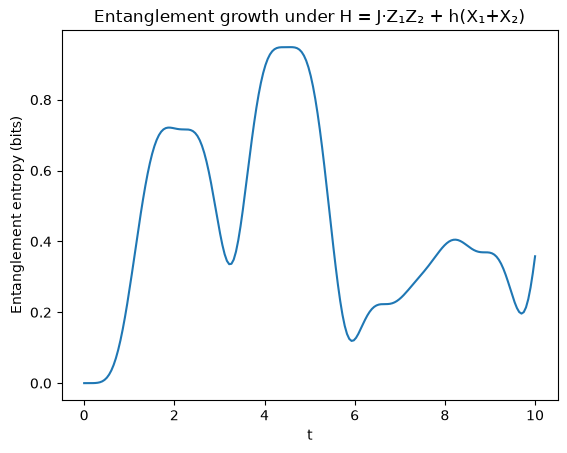

In [8]:

from qiskit.quantum_info import partial_trace, entropy

def entanglement_entropy(state):
    rho1 = partial_trace(state, [1])   # trace out qubit 1, keep qubit 0
    return entropy(rho1, base=2)

import numpy as np
from scipy.linalg import expm
from qiskit.quantum_info import Statevector, partial_trace, entropy
import matplotlib.pyplot as plt

I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])

def kron(*ops):
    result = ops[0]
    for op in ops[1:]:
        result = np.kron(result, op)
    return result

J, h = 1.0, 0.5
H_2q = J * kron(Z, Z) + h * kron(X, I) + h * kron(I, X)
psi0_2q = np.array([1, 0, 0, 0], dtype=complex)   # |00>

def exact_state_2q(H, psi0, t):
    return expm(-1j * H * t) @ psi0

def entanglement_entropy(state_vector):
    sv = Statevector(state_vector)
    rho0 = partial_trace(sv, [1])   # trace out qubit 1, keep qubit 0
    return entropy(rho0, base=2)

t_values = np.linspace(0, 10, 200)
exact_entropy = [entanglement_entropy(exact_state_2q(H_2q, psi0_2q, t)) for t in t_values]

plt.plot(t_values, exact_entropy)
plt.xlabel('t')
plt.ylabel('Entanglement entropy (bits)')
plt.title('Entanglement growth under H = J·Z₁Z₂ + h(X₁+X₂)')
plt.savefig('../figures/entanglement_exact.png', dpi=120)

Entropy starts at exactly 0 (a genuine product state) and rises as the 
interaction builds correlations, but not monotonically. Because this is a 
closed, finite system, JZ₁Z₂ builds entanglement while the local fields 
h(X₁+X₂) partially rotate it away again, this oscillatory behaviour is 
characteristic of small closed quantum systems, distinct from the 
monotonic saturation expected in open or many-body systems. The peaks are 
not perfectly periodic either, since the Hamiltonian's terms don't commute, 
producing quasi-periodic beating rather than simple periodic rotation.

The same Trotterisation approach, now with a two-qubit ZZ-interaction 
gadget (CX–Rz–CX) alongside single-qubit rotations, should reproduce this 
entropy curve as step count increases.

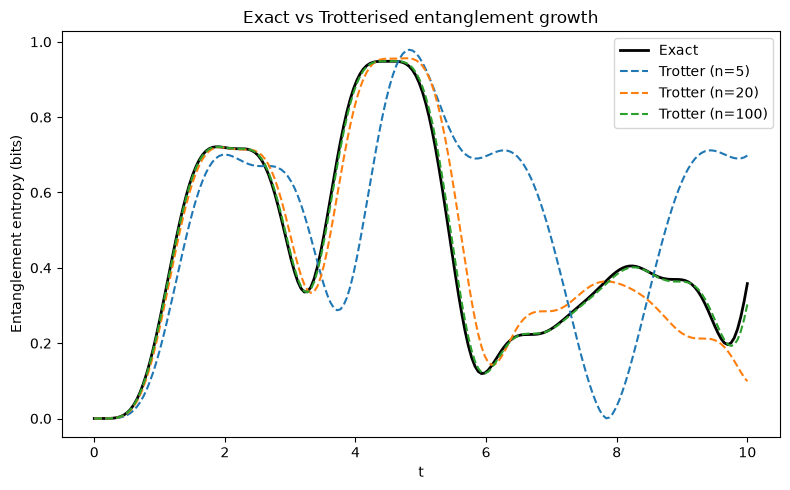

In [ ]:
def trotter_state_2q(J, h, t, n_steps):
    dt = t / n_steps
    qc = QuantumCircuit(2)
    for _ in range(n_steps):
        zz_interaction(qc, 0, 1, 2 * J * dt)
        qc.rx(2 * h * dt, 0)
        qc.rx(2 * h * dt, 1)
    return Statevector(qc)

# Compare exact vs Trotterised entanglement growth at a few step counts
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_values, exact_entropy, label='Exact', linewidth=2, color='black')

for n in [5, 20, 100]:
    trot_entropy = [entanglement_entropy(trotter_state_2q(J, h, t, n)) for t in t_values]
    ax.plot(t_values, trot_entropy, '--', label=f'Trotter (n={n})')

ax.set_xlabel('t')
ax.set_ylabel('Entanglement entropy (bits)')
ax.set_title('Exact vs Trotterised entanglement growth')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/entanglement_trotter_comparison.png', dpi=120)

### Why this matters: the case for quantum simulation

Feynman's original argument for quantum computers was that classical 
simulation cost grows exponentially with system size. This is checked 
directly: classical storage requirements as a function of qubit count.

Text(0.5, 1.0, 'Exponential growth of classical simulation cost')

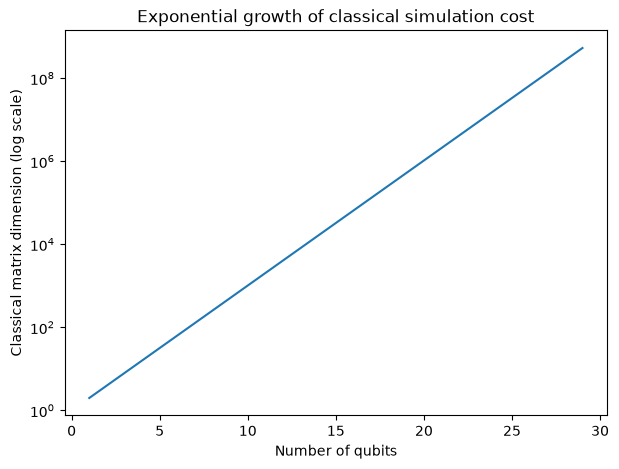

In [10]:
n_qubits = np.arange(1, 30)
hilbert_dim = 2**n_qubits

fig, ax = plt.subplots(figsize=(7,5))
ax.semilogy(n_qubits, hilbert_dim)
ax.set_xlabel('Number of qubits')
ax.set_ylabel('Classical matrix dimension (log scale)')
ax.set_title('Exponential growth of classical simulation cost')

On this log scale, a straight line is the signature of exponential growth: 
log(2ⁿ) = n·log(2), a constant slope. At n=30, this already reaches ~10⁹, 
a billion-dimensional matrix; by n=50, ~10¹⁵, beyond what any classical 
computer could hold in memory.

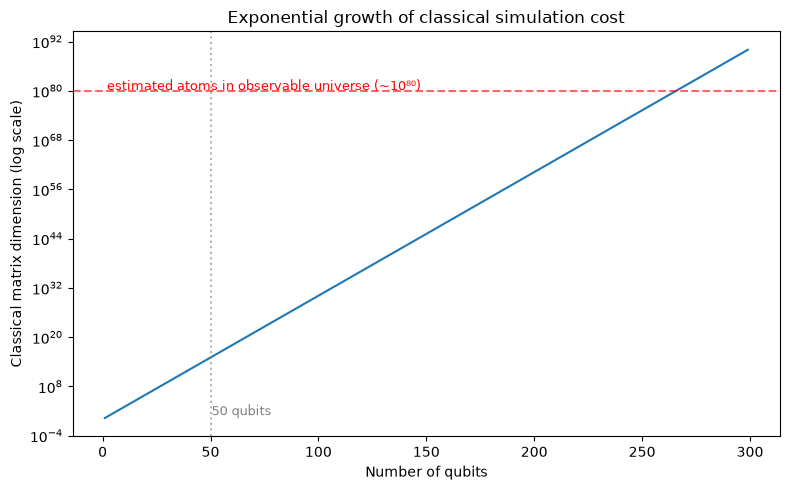

In [11]:
n_qubits = np.arange(1, 300)
hilbert_dim = 2.0**n_qubits

fig, ax = plt.subplots(figsize=(8,5))
ax.semilogy(n_qubits, hilbert_dim)

# Mark meaningful reference points
ax.axhline(1e80, color='red', linestyle='--', alpha=0.6)
ax.text(2, 1e80*1.5, 'estimated atoms in observable universe (~10⁸⁰)', color='red', fontsize=9)

ax.axvline(50, color='gray', linestyle=':', alpha=0.6)
ax.text(50.5, 10, '50 qubits', color='gray', fontsize=9)

ax.set_xlabel('Number of qubits')
ax.set_ylabel('Classical matrix dimension (log scale)')
ax.set_title('Exponential growth of classical simulation cost')
plt.tight_layout()
plt.savefig('../figures/exponential_scaling.png', dpi=120)

Extending the range shows classical storage crossing the estimated number 
of atoms in the observable universe (~10⁸⁰) at roughly 266 qubits. Real 
quantum processors already exceed 100 qubits (IBM Nighthawk: 120, Google 
Willow: 105), meaning no classical computer, even in principle, could store 
the full state vector these devices already operate on.

### From "why quantum simulation" to "why Trotterisation specifically"

The exponential storage argument motivates quantum simulation generally, 
but doesn't yet show why Trotterisation specifically is a practical 
approach. The distinguishing claim: a Trotterised circuit's gate count 
grows only *polynomially* with qubit number, while classical exact 
diagonalisation grows exponentially.

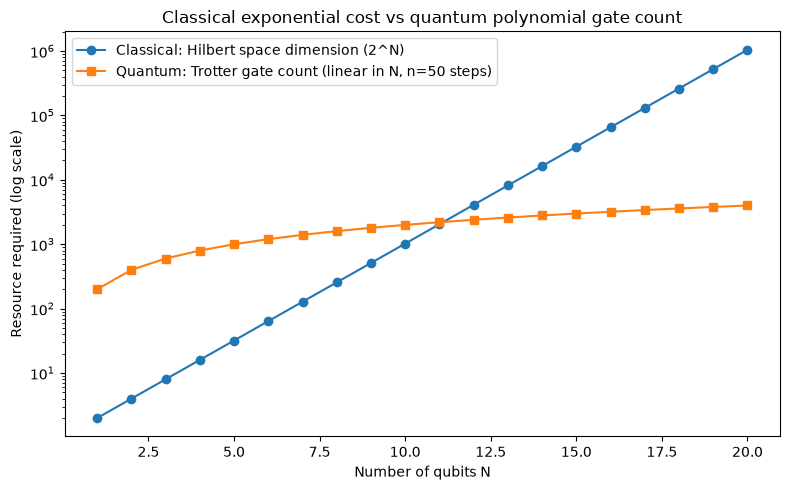

In [13]:
N_qubits = np.arange(1, 21)
classical_dim = 2.0**N_qubits

n_steps_fixed = 50
gates_per_step = 4 * N_qubits   # (N-1) ZZ-gadgets (3 gates each) + N single-qubit rotations ≈ 4N
total_gates = gates_per_step * n_steps_fixed

fig, ax = plt.subplots(figsize=(8,5))
ax.semilogy(N_qubits, classical_dim, 'o-', label='Classical: Hilbert space dimension (2^N)')
ax.semilogy(N_qubits, total_gates, 's-', label=f'Quantum: Trotter gate count (linear in N, n={n_steps_fixed} steps)')
ax.set_xlabel('Number of qubits N')
ax.set_ylabel('Resource required (log scale)')
ax.set_title('Classical exponential cost vs quantum polynomial gate count')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/gate_count_vs_classical.png', dpi=120)

At N=20 qubits, classical storage requires over a million complex numbers, 
while the Trotterised circuit needs only 4000 gates (50 Trotter steps), 
linear growth set against exponential growth, made concrete.

The relevant distinction is polynomial vs exponential *scaling*, not 
absolute speed. A polynomial method may still be slow, but it never hits 
the specific wall that renders exponential methods impossible, regardless 
of available computing power, exactly the wall demonstrated above.

This comparison is intentionally scoped: it does not claim Trotterisation 
is the optimal quantum algorithm (more advanced techniques such as 
qubitization can scale better in certain regimes), nor that no classical 
method could do better for specific structured Hamiltonians (e.g. tensor 
networks). It demonstrates the specific computational wall motivating 
Feynman's original argument, and why polynomial scaling is qualitatively, 
not just quantitatively, different from exponential scaling.